In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string
import nltk

# Download NLTK resources (Run only once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Save Model
import pickle

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [2]:
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv("/content/drive/MyDrive/ML_DL/Datasets/Womens Clothing E-Commerce Reviews.csv")

Mounted at /content/drive


In [3]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
df.tail()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses
23485,23485,1104,52,Please make more like this one!,This dress in a lovely platinum is feminine an...,5,1,22,General Petite,Dresses,Dresses


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [6]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 23486
Columns : 11


In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


In [8]:
df = df.drop(columns=["Unnamed: 0"])

In [9]:
df.shape

(23486, 10)

In [10]:
df.dropna(subset=['Review Text'], inplace=True)

In [11]:
df['Title'] = df['Title'].fillna('')
df['Division Name'] = df['Division Name'].fillna(df['Division Name'].mode()[0])
df['Department Name'] = df['Department Name'].fillna(df['Department Name'].mode()[0])
df['Class Name'] = df['Class Name'].fillna(df['Class Name'].mode()[0])

In [12]:
df.isnull().sum()

,0
Clothing ID,0
Age,0
Title,0
Review Text,0
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,0
Department Name,0
Class Name,0


In [13]:
df.duplicated().sum()

np.int64(1)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.shape

(22640, 10)

In [16]:
def sentiment(rating):

    if rating >= 4:
        return "Positive"

    elif rating == 3:
        return "Neutral"

    else:
        return "Negative"

In [17]:
df["Sentiment"] = df["Rating"].apply(sentiment)

In [18]:
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,17447
Neutral,2823
Negative,2370


In [19]:
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Sentiment
0,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Positive
1,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Positive
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Neutral
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,Positive
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Positive


In [20]:
stop_words = set(stopwords.words("english"))

In [21]:
lemmatizer = WordNetLemmatizer()

In [22]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [23]:
df["Clean Review"] = df["Review Text"].apply(clean_text)

In [24]:
df[["Review Text","Clean Review"]].head()

,Review Text,Clean Review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,love dress sooo pretty happened find store im ...
2,I had such high hopes for this dress and reall...,high hope dress really wanted work initially o...
3,"I love, love, love this jumpsuit. it's fun, fl...",love love love jumpsuit fun flirty fabulous ev...
4,This shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...


In [25]:
df.to_csv("clean_reviews.csv", index=False)

In [26]:
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Sentiment,Clean Review
0,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Positive,absolutely wonderful silky sexy comfortable
1,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Positive,love dress sooo pretty happened find store im ...
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Neutral,high hope dress really wanted work initially o...
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,Positive,love love love jumpsuit fun flirty fabulous ev...
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Positive,shirt flattering due adjustable front tie perf...


In [27]:
X = df["Clean Review"]

y = df["Sentiment"]

In [28]:
print(X.head())
print(y.head())

0          absolutely wonderful silky sexy comfortable
1    love dress sooo pretty happened find store im ...
2    high hope dress really wanted work initially o...
3    love love love jumpsuit fun flirty fabulous ev...
4    shirt flattering due adjustable front tie perf...
Name: Clean Review, dtype: object
0    Positive
1    Positive
2     Neutral
3    Positive
4    Positive
Name: Sentiment, dtype: object


In [29]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X)

In [30]:
print(X.shape)

(22640, 5000)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [32]:
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (18112, 5000)
Testing : (4528, 5000)


In [33]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)
print(classification_report(y_test, nb_pred))
print(confusion_matrix(y_test, nb_pred))

Naive Bayes Accuracy: 0.7815812720848057
              precision    recall  f1-score   support

    Negative       0.78      0.08      0.15       474
     Neutral       0.48      0.02      0.05       565
    Positive       0.78      1.00      0.88      3489

    accuracy                           0.78      4528
   macro avg       0.68      0.37      0.36      4528
weighted avg       0.75      0.78      0.70      4528

[[  39   13  422]
 [  10   14  541]
 [   1    2 3486]]


In [34]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print(classification_report(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))

Logistic Regression Accuracy: 0.8186837455830389
              precision    recall  f1-score   support

    Negative       0.62      0.43      0.51       474
     Neutral       0.43      0.22      0.29       565
    Positive       0.86      0.97      0.91      3489

    accuracy                           0.82      4528
   macro avg       0.64      0.54      0.57      4528
weighted avg       0.78      0.82      0.79      4528

[[ 203   90  181]
 [  92  124  349]
 [  32   77 3380]]


In [35]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print(classification_report(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy: 0.7299028268551236
              precision    recall  f1-score   support

    Negative       0.33      0.30      0.31       474
     Neutral       0.27      0.26      0.26       565
    Positive       0.85      0.87      0.86      3489

    accuracy                           0.73      4528
   macro avg       0.48      0.47      0.48      4528
weighted avg       0.72      0.73      0.73      4528

[[ 140  108  226]
 [ 100  145  320]
 [ 187  282 3020]]


In [36]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))


Random Forest Accuracy: 0.7840106007067138
              precision    recall  f1-score   support

    Negative       0.66      0.12      0.21       474
     Neutral       0.33      0.01      0.02       565
    Positive       0.79      1.00      0.88      3489

    accuracy                           0.78      4528
   macro avg       0.59      0.38      0.37      4528
weighted avg       0.72      0.78      0.70      4528

[[  59   13  402]
 [  26    7  532]
 [   4    1 3484]]


In [37]:
svm = LinearSVC(random_state=42)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)
print(classification_report(y_test, svm_pred))
print(confusion_matrix(y_test, svm_pred))

SVM Accuracy: 0.8257508833922261
              precision    recall  f1-score   support

    Negative       0.60      0.52      0.56       474
     Neutral       0.44      0.27      0.33       565
    Positive       0.89      0.96      0.92      3489

    accuracy                           0.83      4528
   macro avg       0.64      0.58      0.60      4528
weighted avg       0.80      0.83      0.81      4528

[[ 246   89  139]
 [ 118  152  295]
 [  44  104 3341]]


In [38]:
results = pd.DataFrame({

    "Model": [

        "Naive Bayes",

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "SVM"

    ],

    "Accuracy": [

        nb_accuracy,

        lr_accuracy,

        dt_accuracy,

        rf_accuracy,

        svm_accuracy

    ]

})

results

,Model,Accuracy
0,Naive Bayes,0.781581
1,Logistic Regression,0.818684
2,Decision Tree,0.729903
3,Random Forest,0.784011
4,SVM,0.825751


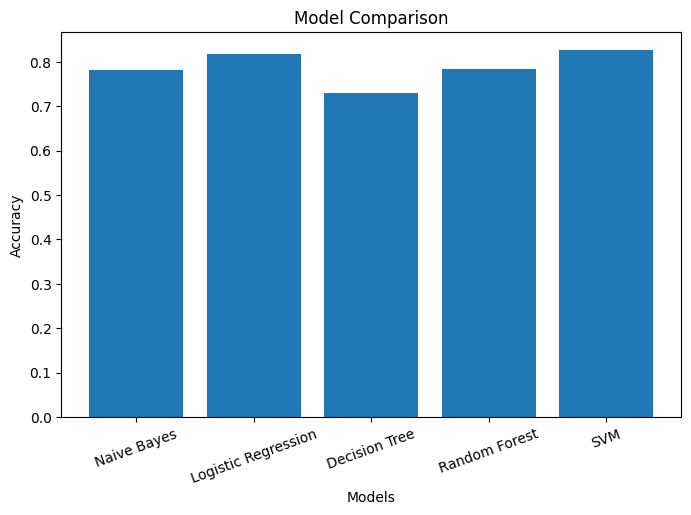

In [39]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

In [40]:
best_model = results.sort_values(
    by="Accuracy",
    ascending=False
)

print(best_model)

                 Model  Accuracy
4                  SVM  0.825751
1  Logistic Regression  0.818684
3        Random Forest  0.784011
0          Naive Bayes  0.781581
2        Decision Tree  0.729903


In [41]:
with open("svm_sentiment_modellll.pkl", "wb") as file:
    pickle.dump(svm, file)

In [42]:
with open("tfidf_vectorizerrrr.pkl", "wb") as file:
    pickle.dump(tfidf, file)

In [43]:
review = "This dress is beautiful and comfortable"

clean_review = clean_text(review)

review_vector = tfidf.transform([clean_review])

prediction = svm.predict(review_vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: Positive


In [44]:
product_df = df[[
    "Clothing ID",
    "Title",
    "Review Text",
    "Rating"
]].copy()

In [45]:
product_df.head()

,Clothing ID,Title,Review Text,Rating
0,767,,Absolutely wonderful - silky and sexy and comf...,4
1,1080,,Love this dress! it's sooo pretty. i happene...,5
2,1077,Some major design flaws,I had such high hopes for this dress and reall...,3
3,1049,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5
4,847,Flattering shirt,This shirt is very flattering to all due to th...,5


In [46]:
product_df = product_df.drop_duplicates(subset="Clothing ID")

In [47]:
print(product_df.shape)

(1179, 4)


In [48]:
product_df["Title"] = product_df["Title"].fillna("No Title")

In [49]:
product_df["Recommendation_Text"] = (
    product_df["Title"] + " " +
    product_df["Review Text"]
)

In [50]:
product_df[["Title","Recommendation_Text"]].head()

,Title,Recommendation_Text
0,,Absolutely wonderful - silky and sexy and com...
1,,Love this dress! it's sooo pretty. i happen...
2,Some major design flaws,Some major design flaws I had such high hopes ...
3,My favorite buy!,"My favorite buy! I love, love, love this jumps..."
4,Flattering shirt,Flattering shirt This shirt is very flattering...


In [51]:
product_df["Clean_Text"] = product_df["Recommendation_Text"].apply(clean_text)

In [52]:
recommend_tfidf = TfidfVectorizer(stop_words="english")

In [53]:
recommend_matrix = recommend_tfidf.fit_transform(
    product_df["Clean_Text"]
)

In [54]:
print(recommend_matrix.shape)

(1179, 3719)


In [55]:
from sklearn.metrics.pairwise import cosine_similarity

In [56]:
cosine_sim = cosine_similarity(recommend_matrix)

In [57]:
print(cosine_sim.shape)

(1179, 1179)


In [58]:
def recommend_products(user_review, top_n=5):

    # Clean user review
    clean_review = clean_text(user_review)

    # Convert to TF-IDF
    user_vector = recommend_tfidf.transform([clean_review])

    # Calculate similarity
    similarity = cosine_similarity(
        user_vector,
        recommend_matrix
    )

    # Get indices of most similar products
    indices = similarity.argsort()[0][-top_n:][::-1]

    # Return recommendations
    recommendations = product_df.iloc[indices][
        ["Clothing ID",
         "Title",
         "Rating"]
    ]

    return recommendations

In [59]:
recommend_products("Beautiful cotton dress")

,Clothing ID,Title,Rating
19299,566,,5
12140,563,Absolutely gorgeous,5
2810,843,Great print!,5
2827,1093,Beautiful dress but too dark,3
11821,1138,Wanted to love it,4


In [60]:
user_review = "This dress is beautiful and comfortable"

# Sentiment Prediction
clean_review = clean_text(user_review)

review_vector = tfidf.transform([clean_review])

sentiment = svm.predict(review_vector)[0]

print("Sentiment :", sentiment)

# Product Recommendation
recommended_products = recommend_products(user_review)

recommended_products

Sentiment : Positive


,Clothing ID,Title,Rating
19299,566,,5
5201,238,Beautiful print and design of suit,5
2827,1093,Beautiful dress but too dark,3
11821,1138,Wanted to love it,4
1160,720,,5


In [61]:
recommendations = recommend_products(user_review)

for i, row in recommendations.iterrows():

    print("Product :", row["Title"])

    print("Rating :", row["Rating"])

    print("-"*40)

Product : 
Rating : 5
----------------------------------------
Product : Beautiful print and design of suit
Rating : 5
----------------------------------------
Product : Beautiful dress but too dark
Rating : 3
----------------------------------------
Product : Wanted to love it
Rating : 4
----------------------------------------
Product : 
Rating : 5
----------------------------------------


In [62]:
with open("recommendtf.pkl","wb") as file:
    pickle.dump(recommend_tfidf,file)

In [63]:
product_df.to_csv(
    "productttt.csv",
    index=False
)

In [64]:
product_df.columns


Index(['Clothing ID', 'Title', 'Review Text', 'Rating', 'Recommendation_Text',
       'Clean_Text'],
      dtype='object')